# GWAS locus summary + gene annotation + pleiotropy

这个 notebook 做 4 件事：

1. 从每个 phenotype 的 GWAS 结果里筛出候选 SNP  
2. 按相邻物理距离把 SNP 合并成 locus，并取每个 locus 的 top SNP  
3. 用 `/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/annotations/KnownCanonicalGene.Drop.hg38.txt` 给 top SNP 做 gene annotation  
4. 跨 phenotype 合并 locus，统计多表型共享位点（pleiotropy）

默认输出文件：

- `data/results/gwas_all/summary/all_locus_summary.tsv`
- `data/results/gwas_all/summary/all_locus_summary.filtered.tsv`
- `data/results/gwas_all/summary/pleiotropy_summary.tsv`
- `data/results/gwas_all/summary/pleiotropy_members.tsv`
- `data/results/gwas_all/summary/phenotype_locus_counts.tsv`

默认逻辑：

- 用 16 个 CPU 多进程
- 先用 `P < 1e-6` 的 SNP 定义 locus
- 同染色体上，相邻 SNP 间距 `<= 250 kb` 归为同一个 locus
- 每个 locus 里取最小 P 的 SNP 作为 top SNP
- `top_p < 5e-8` 记为 `significant`
- `5e-8 <= top_p < 1e-6` 记为 `suggestive`

说明：

- 这个 notebook 默认扫描 `data/results/gwas_all/per_pheno/*/*.glm.linear.add` 和 `*.glm.linear.add.gz`
- 只读必要列，尽量减少内存占用
- gene annotation 做了容错：会自动猜测 chr / start / end / gene 列名
- pleiotropy 这里按 **locus 区间跨 phenotype 再合并**；同染色体上，如果下一个 locus 的 `start <= 当前合并块 end + 250 kb`，就归到同一个 pleiotropic block


In [1]:

from pathlib import Path
import os
import re
import gzip
import math
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
from IPython.display import display

# =========================
# 项目路径
# =========================
PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
PER_PHENO_DIR = PROJECT_ROOT / "data/results/gwas_all/per_pheno"
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

GENE_ANNOTATION_FILE = PROJECT_ROOT / "data/annotations/KnownCanonicalGene.Drop.hg38.txt"

ALL_LOCUS_OUT = SUMMARY_DIR / "all_locus_summary.tsv"
ALL_LOCUS_FILTERED_OUT = SUMMARY_DIR / "all_locus_summary.filtered.tsv"
PLEIOTROPY_SUMMARY_OUT = SUMMARY_DIR / "pleiotropy_summary.tsv"
PLEIOTROPY_MEMBERS_OUT = SUMMARY_DIR / "pleiotropy_members.tsv"
PHENO_LOCUS_COUNTS_OUT = SUMMARY_DIR / "phenotype_locus_counts.tsv"

# =========================
# 参数
# =========================
N_WORKERS = 16
LOCUS_P_THRESHOLD = 1e-6
GENOME_WIDE_SIG = 5e-8
MERGE_DISTANCE_BP = 250_000
NEAREST_GENE_MAX_DISTANCE_BP = 500_000

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PER_PHENO_DIR:", PER_PHENO_DIR)
print("SUMMARY_DIR:", SUMMARY_DIR)
print("GENE_ANNOTATION_FILE:", GENE_ANNOTATION_FILE)


PROJECT_ROOT: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation
PER_PHENO_DIR: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/per_pheno
SUMMARY_DIR: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary
GENE_ANNOTATION_FILE: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/annotations/KnownCanonicalGene.Drop.hg38.txt


## Step 1. 基础检查与结果文件扫描

这里先检查目录是否存在，再扫描全部 phenotype 的 ADD 结果文件。  
兼容两种情况：

- `*.glm.linear.add`
- `*.glm.linear.add.gz`


In [2]:

def check_exists(fp: Path):
    if not fp.exists():
        raise FileNotFoundError(f"文件不存在: {fp}")

check_exists(PER_PHENO_DIR)

def list_add_files(per_pheno_dir: Path):
    files = []
    for f in per_pheno_dir.glob("*/*.glm.linear.add"):
        if f.is_file():
            files.append(f)
    for f in per_pheno_dir.glob("*/*.glm.linear.add.gz"):
        if f.is_file():
            files.append(f)
    return sorted(set(files))

add_files = list_add_files(PER_PHENO_DIR)

print("n_add_files:", len(add_files))
if len(add_files) == 0:
    raise RuntimeError(f"没有在 {PER_PHENO_DIR} 下找到 *.glm.linear.add 或 *.glm.linear.add.gz")

file_df = pd.DataFrame({
    "phenotype": [f.parent.name for f in add_files],
    "add_file": [str(f) for f in add_files],
})
display(file_df.head())


n_add_files: 1532


,phenotype,add_file
0,Acesulfame,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
1,Acetic_acid,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
2,Acetylglycine,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
3,Adenosine_monophosphate,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
4,Adipic_acid,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...


## Step 2. 定义单文件 locus 汇总函数

这一步只读取必要列，并且按下面逻辑处理：

1. 只保留 `TEST == ADD`（如果文件里有 `TEST` 列）
2. 只保留 `P < 1e-6`
3. 按染色体和位置排序
4. 在每个染色体内，按相邻 SNP 距离 `<= 250 kb` 聚成一个 locus
5. 每个 locus 取最小 P 的 SNP 作为 top SNP


In [3]:

USECOL_CANDIDATES = {
    "#CHROM", "CHROM", "CHR", "POS", "ID", "P", "BETA", "SE", "ERRCODE", "TEST"
}

def normalize_chr(x):
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return np.nan
    s = s.replace("#", "")
    s = re.sub(r"^chr", "", s, flags=re.IGNORECASE).strip()
    mapping = {"X": 23, "Y": 24, "M": 25, "MT": 25}
    if s.upper() in mapping:
        return mapping[s.upper()]
    try:
        v = int(float(s))
        return v
    except Exception:
        return np.nan

def signal_label_from_top_p(top_p: float):
    if pd.isna(top_p):
        return "unknown"
    if top_p < GENOME_WIDE_SIG:
        return "significant"
    if top_p < LOCUS_P_THRESHOLD:
        return "suggestive"
    return "other"

def read_gwas_add_file(add_file: Path) -> pd.DataFrame:
    df = pd.read_csv(
        add_file,
        sep="\t",
        compression="infer",
        usecols=lambda c: c in USECOL_CANDIDATES,
        low_memory=False
    )
    return df

def summarize_one_add_file(add_file_str: str) -> pd.DataFrame:
    add_file = Path(add_file_str)
    phenotype = add_file.parent.name

    try:
        df = read_gwas_add_file(add_file)
    except Exception as e:
        return pd.DataFrame([{
            "phenotype": phenotype,
            "source_file": str(add_file),
            "parse_status": f"read_failed: {e}",
        }])

    if df.shape[0] == 0:
        return pd.DataFrame([{
            "phenotype": phenotype,
            "source_file": str(add_file),
            "parse_status": "empty_file",
        }])

    chrom_col = "#CHROM" if "#CHROM" in df.columns else ("CHROM" if "CHROM" in df.columns else ("CHR" if "CHR" in df.columns else None))
    if chrom_col is None:
        return pd.DataFrame([{
            "phenotype": phenotype,
            "source_file": str(add_file),
            "parse_status": "missing_chrom_col",
        }])

    if "TEST" in df.columns:
        df = df[df["TEST"].astype(str) == "ADD"].copy()

    if "ERRCODE" in df.columns:
        df = df[df["ERRCODE"].isna() | (df["ERRCODE"].astype(str).str.strip() == ".")].copy()

    keep_cols = [c for c in [chrom_col, "POS", "ID", "P", "BETA", "SE"] if c in df.columns]
    df = df[keep_cols].copy()

    df["chrom"] = df[chrom_col].map(normalize_chr)
    df["pos"] = pd.to_numeric(df["POS"], errors="coerce")
    df["p"] = pd.to_numeric(df["P"], errors="coerce")

    if "BETA" in df.columns:
        df["beta"] = pd.to_numeric(df["BETA"], errors="coerce")
    else:
        df["beta"] = np.nan

    if "SE" in df.columns:
        df["se"] = pd.to_numeric(df["SE"], errors="coerce")
    else:
        df["se"] = np.nan

    df["snp_id"] = df["ID"].astype(str) if "ID" in df.columns else np.nan

    df = df[
        df["chrom"].notna() &
        df["pos"].notna() &
        df["p"].notna() &
        np.isfinite(df["p"]) &
        (df["p"] > 0) &
        (df["p"] < LOCUS_P_THRESHOLD)
    ].copy()

    if df.shape[0] == 0:
        return pd.DataFrame([{
            "phenotype": phenotype,
            "source_file": str(add_file),
            "parse_status": "no_snp_below_threshold",
        }])

    df["chrom"] = df["chrom"].astype(int)
    df["pos"] = df["pos"].astype(int)
    df = df.sort_values(["chrom", "pos", "p", "snp_id"]).reset_index(drop=True)

    all_locus_records = []
    for chrom, sub in df.groupby("chrom", sort=True):
        sub = sub.sort_values(["pos", "p", "snp_id"]).reset_index(drop=True)
        gap = sub["pos"].diff()
        sub["local_locus_idx"] = (gap.isna() | (gap > MERGE_DISTANCE_BP)).cumsum()

        for local_locus_idx, locus_df in sub.groupby("local_locus_idx", sort=True):
            locus_df = locus_df.sort_values(["p", "pos", "snp_id"]).reset_index(drop=True)
            top = locus_df.iloc[0]

            locus_start = int(locus_df["pos"].min())
            locus_end = int(locus_df["pos"].max())
            top_pos = int(top["pos"])
            top_p = float(top["p"])

            locus_id = f"chr{chrom}:{locus_start}-{locus_end}"

            all_locus_records.append({
                "phenotype": phenotype,
                "source_file": str(add_file),
                "parse_status": "ok",
                "locus_id": locus_id,
                "chrom": chrom,
                "start": locus_start,
                "top": top_pos,
                "end": locus_end,
                "n_snp": int(locus_df.shape[0]),
                "top_snp_id": top.get("snp_id", np.nan),
                "top_p": top_p,
                "top_beta": float(top["beta"]) if pd.notna(top["beta"]) else np.nan,
                "top_se": float(top["se"]) if pd.notna(top["se"]) else np.nan,
                "status": signal_label_from_top_p(top_p),
            })

    out = pd.DataFrame(all_locus_records)
    return out

print("single-file function ready")


single-file function ready


## Step 3. 多进程汇总全部 phenotype 的 locus

这一段会启动 16 个进程。  
输出先写 `all_locus_summary.tsv`，后面再继续做 gene annotation 和 pleiotropy。


In [4]:

results = []
done = 0
total = len(add_files)

with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    future_map = {ex.submit(summarize_one_add_file, str(f)): f for f in add_files}
    for fut in as_completed(future_map):
        add_file = future_map[fut]
        done += 1
        try:
            df = fut.result()
            results.append(df)
            if done % 20 == 0 or done == total:
                print(f"[{done}/{total}] done: {add_file.parent.name}")
        except Exception as e:
            print(f"[FAILED] {add_file}: {e}")
            results.append(pd.DataFrame([{
                "phenotype": add_file.parent.name,
                "source_file": str(add_file),
                "parse_status": f"worker_failed: {e}",
            }]))

all_locus_raw = pd.concat(results, ignore_index=True)

for c in ["chrom", "start", "top", "end", "n_snp", "top_p", "top_beta", "top_se"]:
    if c in all_locus_raw.columns:
        all_locus_raw[c] = pd.to_numeric(all_locus_raw[c], errors="coerce")

# 先保存一份 raw locus summary
all_locus_raw.to_csv(ALL_LOCUS_OUT, sep="\t", index=False)

print("saved:", ALL_LOCUS_OUT)
print("all_locus_raw shape:", all_locus_raw.shape)
display(all_locus_raw.head())
display(all_locus_raw["parse_status"].value_counts(dropna=False).rename_axis("parse_status").reset_index(name="n"))


[20/1532] done: But_2_enoic_acid
[40/1532] done: DAG_16_1_18_2
[60/1532] done: DAG_18_1_20_2
[80/1532] done: DAG_20_1_22_3
[100/1532] done: Dioxolithocholic_Acid
[120/1532] done: Gamma_Aminobutyric_acid
[140/1532] done: Hippuric_acid
[160/1532] done: LPC_14_0
[180/1532] done: LPC_22_1
[200/1532] done: LPE_20_4
[220/1532] done: L_Homocitrulline
[240/1532] done: Murocholic_acid
[260/1532] done: N_Phenylacetylphenylalanine
[280/1532] done: PC_16_0_20_5
[300/1532] done: PC_16_1_18_4
[320/1532] done: PC_18_0_20_4
[340/1532] done: PC_18_1_22_1
[360/1532] done: PC_18_2_22_3
[380/1532] done: PC_18_4_20_5
[400/1532] done: PC_20_0_22_2
[420/1532] done: PC_20_2_22_1
[440/1532] done: PC_20_4_22_1
[460/1532] done: PC_22_1_22_3
[480/1532] done: PE_16_0_18_0
[500/1532] done: PE_16_1_18_1
[520/1532] done: PE_18_0_18_3
[540/1532] done: PE_18_1_20_5
[560/1532] done: PE_18_2_22_1
[580/1532] done: PE_18_4_20_0
[600/1532] done: PE_20_0_20_2
[620/1532] done: PE_20_2_20_5
[640/1532] done: PE_20_4_22_1
[660/1

,phenotype,source_file,parse_status,locus_id,chrom,start,top,end,n_snp,top_snp_id,top_p,top_beta,top_se,status
0,Adenosine_monophosphate,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr3:158984691-158984691,3.0,158984691.0,158984691.0,158984691.0,1.0,chr3_158984691,9.735440e-07,-0.958644,0.192310,suggestive
1,Adenosine_monophosphate,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr13:24085587-24085587,13.0,24085587.0,24085587.0,24085587.0,1.0,chr13_24085587,7.420890e-07,0.380724,0.075543,suggestive
2,Adenosine_monophosphate,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr22:50541317-50541317,22.0,50541317.0,50541317.0,50541317.0,1.0,chr22_50541317,6.635210e-07,1.793720,0.354283,suggestive
3,Beta_Hyodeoxycholic_Acid,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr13:107496121-107496121,13.0,107496121.0,107496121.0,107496121.0,1.0,chr13_107496121,8.850730e-07,0.375491,0.075045,suggestive
4,Beta_Hyodeoxycholic_Acid,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr20:32376863-32376863,20.0,32376863.0,32376863.0,32376863.0,1.0,chr20_32376863,9.609030e-07,-0.524621,0.105206,suggestive


,parse_status,n
0,ok,2695
1,no_snp_below_threshold,280


## Step 4. 给 top SNP 做 gene annotation

这里按 `top SNP` 的染色体和位置去做 annotation：

- 如果 top SNP 落在基因区间内，记为 `overlap`
- 否则找最近基因，距离不超过 `500 kb`
- `gene` 列优先写 overlap gene；如果没有 overlap，就写最近基因


In [6]:

def guess_col(cols, candidates):
    colmap = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in colmap:
            return colmap[cand.lower()]
    for c in cols:
        lc = str(c).lower()
        for cand in candidates:
            if lc == cand.lower():
                return c
    return None

def load_gene_annotation(annotation_file: Path) -> pd.DataFrame:
    check_exists(annotation_file)

    with open(annotation_file, "r", encoding="utf-8", errors="ignore") as f:
        preview_lines = []
        for _ in range(5):
            line = f.readline()
            if not line:
                break
            preview_lines.append(line.rstrip("\n"))

    non_comment_lines = [x for x in preview_lines if x.strip() and not x.startswith("#")]

    use_header_none = False
    if len(non_comment_lines) > 0:
        first_fields = non_comment_lines[0].split("\t")
        if len(first_fields) >= 5:
            first0 = str(first_fields[0]).strip().lower()
            first1 = str(first_fields[1]).strip()
            first2 = str(first_fields[2]).strip()
            if first0.startswith("chr") and first1.isdigit() and first2.isdigit():
                use_header_none = True

    if use_header_none:
        ann = pd.read_csv(
            annotation_file,
            sep="\t",
            comment="#",
            header=None,
            low_memory=False
        )
        if ann.shape[1] < 5:
            raise ValueError(f"gene annotation 文件列数不足：{annotation_file}")
        ann = ann.iloc[:, [0, 1, 2, 4]].copy()
        ann.columns = ["chrom_raw", "start", "end", "gene"]
    else:
        ann = pd.read_csv(annotation_file, sep="\t", low_memory=False)

        chrom_col = guess_col(ann.columns, ["chrom", "#chrom", "chr", "hg38.knownCanonical.chrom"])
        start_col = guess_col(ann.columns, ["txStart", "start", "chromStart", "geneStart", "hg38.knownCanonical.chromStart"])
        end_col = guess_col(ann.columns, ["txEnd", "end", "chromEnd", "geneEnd", "hg38.knownCanonical.chromEnd"])
        gene_col = guess_col(ann.columns, ["gene", "gene_name", "symbol", "name2", "geneSymbol", "hgnc_symbol", "hg38.kgXref.geneSymbol"])

        missing = [x for x in {
            "chrom_col": chrom_col,
            "start_col": start_col,
            "end_col": end_col,
            "gene_col": gene_col,
        }.items() if x[1] is None]
        if missing:
            raise ValueError(
                "gene annotation 文件列名识别失败，当前列为：\n"
                f"{list(ann.columns)}\n"
                "至少需要能识别 chrom/start/end/gene 四类列。"
            )

        ann = ann[[chrom_col, start_col, end_col, gene_col]].copy()
        ann.columns = ["chrom_raw", "start", "end", "gene"]

    ann["chrom"] = ann["chrom_raw"].map(normalize_chr)
    ann["start"] = pd.to_numeric(ann["start"], errors="coerce")
    ann["end"] = pd.to_numeric(ann["end"], errors="coerce")
    ann["gene"] = ann["gene"].astype(str).str.strip()

    ann = ann[
        ann["chrom"].notna() &
        ann["start"].notna() &
        ann["end"].notna() &
        ann["gene"].notna() &
        (ann["gene"] != "") &
        (ann["gene"].str.lower() != "nan")
    ].copy()

    ann["chrom"] = ann["chrom"].astype(int)
    ann["start"] = ann["start"].astype(int)
    ann["end"] = ann["end"].astype(int)

    ann = ann.sort_values(["chrom", "start", "end", "gene"]).drop_duplicates().reset_index(drop=True)
    return ann

def annotate_top_snps(locus_df: pd.DataFrame, ann_df: pd.DataFrame) -> pd.DataFrame:
    locus_df = locus_df.copy()
    locus_df["gene"] = np.nan
    locus_df["gene_hit_type"] = np.nan
    locus_df["gene_distance_bp"] = np.nan
    locus_df["overlap_gene_n"] = 0

    ann_by_chr = {chrom: sub.reset_index(drop=True) for chrom, sub in ann_df.groupby("chrom", sort=False)}

    gene_list = []
    hit_type_list = []
    dist_list = []
    overlap_n_list = []

    for row in locus_df.itertuples(index=False):
        chrom = int(row.chrom)
        pos = int(row.top)

        sub = ann_by_chr.get(chrom)
        if sub is None or sub.shape[0] == 0:
            gene_list.append(np.nan)
            hit_type_list.append("no_chr_annotation")
            dist_list.append(np.nan)
            overlap_n_list.append(0)
            continue

        overlap = sub[(sub["start"] <= pos) & (sub["end"] >= pos)].copy()
        if overlap.shape[0] > 0:
            genes = sorted(overlap["gene"].dropna().astype(str).unique())
            gene_list.append(";".join(genes))
            hit_type_list.append("overlap")
            dist_list.append(0)
            overlap_n_list.append(len(genes))
            continue

        dist = np.minimum((sub["start"] - pos).abs(), (sub["end"] - pos).abs())
        idx = dist.idxmin()
        min_dist = int(dist.loc[idx])
        nearest_gene = str(sub.loc[idx, "gene"])

        if min_dist <= NEAREST_GENE_MAX_DISTANCE_BP:
            gene_list.append(nearest_gene)
            hit_type_list.append("nearest")
            dist_list.append(min_dist)
            overlap_n_list.append(0)
        else:
            gene_list.append(np.nan)
            hit_type_list.append("no_gene_within_500kb")
            dist_list.append(min_dist)
            overlap_n_list.append(0)

    locus_df["gene"] = gene_list
    locus_df["gene_hit_type"] = hit_type_list
    locus_df["gene_distance_bp"] = dist_list
    locus_df["overlap_gene_n"] = overlap_n_list
    return locus_df

valid_locus_df = all_locus_raw[all_locus_raw["parse_status"] == "ok"].copy()
valid_locus_df = valid_locus_df[
    valid_locus_df["chrom"].notna() &
    valid_locus_df["start"].notna() &
    valid_locus_df["top"].notna() &
    valid_locus_df["end"].notna() &
    valid_locus_df["top_p"].notna()
].copy()

gene_ann_df = load_gene_annotation(GENE_ANNOTATION_FILE)
print("gene_ann_df shape:", gene_ann_df.shape)
display(gene_ann_df.head())

annotated_locus_df = annotate_top_snps(valid_locus_df, gene_ann_df).copy()

# 回写 raw summary（让 all_locus_summary.tsv 也带 gene annotation）
all_locus_with_ann = all_locus_raw.merge(
    annotated_locus_df[
        ["phenotype", "source_file", "locus_id", "gene", "gene_hit_type", "gene_distance_bp", "overlap_gene_n"]
    ],
    on=["phenotype", "source_file", "locus_id"],
    how="left"
)

ordered_cols = [
    "phenotype", "locus_id", "chrom", "start", "top", "end", "n_snp",
    "gene", "gene_hit_type", "gene_distance_bp", "overlap_gene_n",
    "top_snp_id", "top_p", "top_beta", "top_se", "status",
    "source_file", "parse_status"
]
ordered_cols = [c for c in ordered_cols if c in all_locus_with_ann.columns] + [c for c in all_locus_with_ann.columns if c not in ordered_cols]
all_locus_with_ann = all_locus_with_ann[ordered_cols].copy()
all_locus_with_ann.to_csv(ALL_LOCUS_OUT, sep="\t", index=False)

print("updated with annotation:", ALL_LOCUS_OUT)
display(all_locus_with_ann.head())


gene_ann_df shape: (39194, 5)


,chrom_raw,start,end,gene,chrom
0,chr1,11868,14409,DDX11L1,1
1,chr1,14403,29570,WASH7P,1
2,chr1,17368,17436,MIR6859-1,1
3,chr1,29553,31097,MIR1302-2HG,1
4,chr1,30365,30503,MIR1302-2,1


updated with annotation: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/all_locus_summary.tsv


,phenotype,locus_id,chrom,start,top,end,n_snp,gene,gene_hit_type,gene_distance_bp,overlap_gene_n,top_snp_id,top_p,top_beta,top_se,status,source_file,parse_status
0,Adenosine_monophosphate,chr3:158984691-158984691,3.0,158984691.0,158984691.0,158984691.0,1.0,IQCJ-SCHIP1,nearest,84572.0,0.0,chr3_158984691,9.735440e-07,-0.958644,0.192310,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok
1,Adenosine_monophosphate,chr13:24085587-24085587,13.0,24085587.0,24085587.0,24085587.0,1.0,IPO7P2,nearest,36477.0,0.0,chr13_24085587,7.420890e-07,0.380724,0.075543,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok
2,Adenosine_monophosphate,chr22:50541317-50541317,22.0,50541317.0,50541317.0,50541317.0,1.0,KLHDC7B,nearest,4581.0,0.0,chr22_50541317,6.635210e-07,1.793720,0.354283,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok
3,Beta_Hyodeoxycholic_Acid,chr13:107496121-107496121,13.0,107496121.0,107496121.0,107496121.0,1.0,FAM155A,overlap,0.0,1.0,chr13_107496121,8.850730e-07,0.375491,0.075045,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok
4,Beta_Hyodeoxycholic_Acid,chr20:32376863-32376863,20.0,32376863.0,32376863.0,32376863.0,1.0,ASXL1,overlap,0.0,1.0,chr20_32376863,9.609030e-07,-0.524621,0.105206,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok


## Step 5. 生成 filtered locus summary

这里保留真正可用于下游统计的 locus。  
因为 locus 本身就是在 `P < 1e-6` 的 SNP 上定义出来的，所以这里主要做的是：

- 只保留 `parse_status == ok`
- 只保留有效坐标
- 重新确认 `status` 为 `significant / suggestive`


In [7]:

filtered_locus_df = annotated_locus_df.copy()

filtered_locus_df = filtered_locus_df[
    filtered_locus_df["chrom"].between(1, 25, inclusive="both") &
    filtered_locus_df["start"].notna() &
    filtered_locus_df["top"].notna() &
    filtered_locus_df["end"].notna() &
    filtered_locus_df["top_p"].notna() &
    (filtered_locus_df["start"] <= filtered_locus_df["top"]) &
    (filtered_locus_df["top"] <= filtered_locus_df["end"])
].copy()

filtered_locus_df["status"] = filtered_locus_df["top_p"].map(signal_label_from_top_p)
filtered_locus_df = filtered_locus_df[filtered_locus_df["status"].isin(["significant", "suggestive"])].copy()

filtered_locus_df = filtered_locus_df.sort_values(["chrom", "start", "top_p", "phenotype"]).reset_index(drop=True)
filtered_locus_df.to_csv(ALL_LOCUS_FILTERED_OUT, sep="\t", index=False)

print("saved:", ALL_LOCUS_FILTERED_OUT)
print("filtered_locus_df shape:", filtered_locus_df.shape)
display(filtered_locus_df.head())
display(filtered_locus_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="n"))


saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/all_locus_summary.filtered.tsv
filtered_locus_df shape: (2695, 18)


,phenotype,source_file,parse_status,locus_id,chrom,start,top,end,n_snp,top_snp_id,top_p,top_beta,top_se,status,gene,gene_hit_type,gene_distance_bp,overlap_gene_n
0,PI_20_1_22_6,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr1:907236-907236,1.0,907236.0,907236.0,907236.0,1.0,chr1_907236,8.745300e-07,0.711670,0.136913,suggestive,LINC02593,nearest,9633,0
1,Cer_d18_1_24_0,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr1:2370252-2370252,1.0,2370252.0,2370252.0,2370252.0,1.0,chr1_2370252,1.028760e-07,0.415882,0.076532,suggestive,MORN1,overlap,0,1
2,SM_42_1,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr1:2370252-2370252,1.0,2370252.0,2370252.0,2370252.0,1.0,chr1_2370252,7.425100e-07,0.387975,0.076972,suggestive,MORN1,overlap,0,1
3,PC_20_1_22_0,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr1:2896883-2917445,1.0,2896883.0,2912986.0,2917445.0,11.0,chr1_2912986,2.066710e-07,-0.654028,0.119367,suggestive,ACTRT2,nearest,108480,0
4,PC_18_3_20_2,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,chr1:3883004-3883004,1.0,3883004.0,3883004.0,3883004.0,1.0,chr1_3883004,9.596620e-07,-0.756123,0.149342,suggestive,DFFB,overlap,0,1


,status,n
0,suggestive,2565
1,significant,130


## Step 6. 跨 phenotype 合并 locus，统计 pleiotropy

这里把不同 phenotype 的 locus 再按染色体位置合并成 pleiotropic block。  
合并规则：

- 同染色体
- 下一个 locus 的 `start <= 当前 block end + 250 kb`

输出两个表：

- `pleiotropy_members.tsv`：每个 block 里有哪些 phenotype-locus 成员
- `pleiotropy_summary.tsv`：每个 block 的汇总统计


In [8]:

def build_pleiotropy_blocks(locus_df: pd.DataFrame) -> pd.DataFrame:
    locus_df = locus_df.copy().sort_values(["chrom", "start", "end", "top_p"]).reset_index(drop=True)

    block_records = []
    block_id_counter = 0

    for chrom, sub in locus_df.groupby("chrom", sort=True):
        sub = sub.sort_values(["start", "end", "top_p"]).reset_index(drop=True)

        current_rows = []
        current_start = None
        current_end = None

        def flush_current():
            nonlocal block_id_counter, current_rows, current_start, current_end
            if len(current_rows) == 0:
                return
            block_id_counter += 1
            block_id = f"PB{block_id_counter:05d}"

            block_df = pd.DataFrame(current_rows).copy()
            block_df["pleiotropy_block_id"] = block_id
            block_df["pleiotropy_chrom"] = int(chrom)
            block_df["pleiotropy_start"] = int(current_start)
            block_df["pleiotropy_end"] = int(current_end)
            block_records.append(block_df)

            current_rows = []
            current_start = None
            current_end = None

        for row in sub.to_dict("records"):
            row_start = int(row["start"])
            row_end = int(row["end"])

            if current_start is None:
                current_rows = [row]
                current_start = row_start
                current_end = row_end
                continue

            if row_start <= current_end + MERGE_DISTANCE_BP:
                current_rows.append(row)
                current_end = max(current_end, row_end)
            else:
                flush_current()
                current_rows = [row]
                current_start = row_start
                current_end = row_end

        flush_current()

    if len(block_records) == 0:
        return pd.DataFrame()

    members = pd.concat(block_records, ignore_index=True)
    return members

pleiotropy_members = build_pleiotropy_blocks(filtered_locus_df)

if pleiotropy_members.shape[0] == 0:
    raise RuntimeError("没有生成 pleiotropy_members，通常说明 filtered_locus_df 为空。")

pleiotropy_members["block_min_top_p"] = pleiotropy_members.groupby("pleiotropy_block_id")["top_p"].transform("min")
pleiotropy_members["n_phenotype_in_block"] = pleiotropy_members.groupby("pleiotropy_block_id")["phenotype"].transform("nunique")
pleiotropy_members["n_locus_in_block"] = pleiotropy_members.groupby("pleiotropy_block_id")["locus_id"].transform("nunique")

pleiotropy_members = pleiotropy_members.sort_values(
    ["pleiotropy_chrom", "pleiotropy_start", "block_min_top_p", "phenotype", "top_p"]
).reset_index(drop=True)

pleiotropy_members.to_csv(PLEIOTROPY_MEMBERS_OUT, sep="\t", index=False)
print("saved:", PLEIOTROPY_MEMBERS_OUT)

pleiotropy_summary = (
    pleiotropy_members
    .groupby("pleiotropy_block_id", as_index=False)
    .agg(
        chrom=("pleiotropy_chrom", "first"),
        start=("pleiotropy_start", "first"),
        end=("pleiotropy_end", "first"),
        n_phenotype=("phenotype", "nunique"),
        n_locus=("locus_id", "nunique"),
        min_top_p=("top_p", "min"),
        n_significant=("status", lambda s: int((pd.Series(s) == "significant").sum())),
        n_suggestive=("status", lambda s: int((pd.Series(s) == "suggestive").sum())),
        phenotype_list=("phenotype", lambda x: ";".join(sorted(pd.Series(x).astype(str).unique()))),
        gene_list=("gene", lambda x: ";".join(sorted({g for g in pd.Series(x).dropna().astype(str) if g != ""}))),
        lead_snp_list=("top_snp_id", lambda x: ";".join(sorted({str(v) for v in pd.Series(x).dropna() if str(v) != "nan"}))),
        top_pos_list=("top", lambda x: ";".join(map(str, sorted(pd.Series(x).dropna().astype(int).unique())))),
    )
    .sort_values(["n_phenotype", "n_locus", "min_top_p", "chrom", "start"], ascending=[False, False, True, True, True])
    .reset_index(drop=True)
)

pleiotropy_summary["pleiotropy_level"] = np.where(
    pleiotropy_summary["n_phenotype"] >= 2,
    "shared",
    "single_phenotype"
)

pleiotropy_summary.to_csv(PLEIOTROPY_SUMMARY_OUT, sep="\t", index=False)
print("saved:", PLEIOTROPY_SUMMARY_OUT)

display(pleiotropy_summary.head(20))


saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/pleiotropy_members.tsv
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/pleiotropy_summary.tsv


,pleiotropy_block_id,chrom,start,end,n_phenotype,n_locus,min_top_p,n_significant,n_suggestive,phenotype_list,gene_list,lead_snp_list,top_pos_list,pleiotropy_level
0,PB01139,11,65246264,65418395,26,2,2.773820e-09,3,23,P_7Z_Hexadecenoic_Acid;TAG46_3_FA18_1;TAG50_1_...,NEAT1;SLC22A20P,chr11_65246264;chr11_65418395,65246264;65418395,shared
1,PB01424,15,98731960,98841680,24,16,2.763740e-08,2,22,DAG_18_1_18_2;DAG_18_1_20_1;TAG48_3_FA12_0;TAG...,IGF1R,chr15_98731960;chr15_98742424;chr15_98796604;c...,98731960;98742424;98796604;98799367;98801652;9...,shared
2,PB00167,2,44986262,45607789,24,11,3.155800e-08,2,22,Chenodeoxycholic_acid;DAG_16_0_18_3;PC_18_3_18...,LINC01121;SIX2;SRBD1,chr2_44986262;chr2_45199873;chr2_45426911;chr2...,44986262;45199873;45426911;45532984;45558685;4...,shared
3,PB00880,8,72605714,72756863,20,4,2.190780e-09,1,19,DAG_18_1_20_2;DAG_18_1_20_4;TAG56_5_FA18_0;TAG...,KCNB2,chr8_72746337;chr8_72752660,72746337;72752660,shared
4,PB01441,16,11650396,11791587,18,15,3.965740e-08,1,17,DAG_16_0_18_2;DAG_18_0_18_1;DAG_18_0_18_2;PE_1...,SNN;TXNDC11;ZC3H7A,chr16_11650396;chr16_11713110;chr16_11720240;c...,11650396;11713110;11720240;11743895;11751903;1...,shared
5,PB00065,1,102439672,102475773,18,2,1.356710e-07,0,18,Cholic_Acid;DAG_18_1_18_2;TAG42_2_FA18_2;TAG44...,COL11A1,chr1_102439672;chr1_102475773,102439672;102475773,shared
6,PB01200,12,19394237,19544790,16,10,1.469860e-07,0,16,TAG44_2_FA18_2;TAG46_3_FA12_0;TAG46_3_FA18_2;T...,AEBP2;PDCD5P1,chr12_19397950;chr12_19398280;chr12_19434182;c...,19397950;19398280;19434182;19499614;19500818,shared
7,PB01035,10,12671911,12757139,14,2,2.044280e-08,4,10,PS_18_2_18_3;TAG44_0_FA12_0;TAG44_0_FA14_0;TAG...,CAMK1D,chr10_12671911;chr10_12757139,12671911;12757139,shared
8,PB00017,1,19635054,19960391,12,4,9.964380e-08,0,12,PC_18_1_22_0;PC_20_5_20_5;TAG54_5_FA20_5;TAG54...,MICOS10-NBL1;NBL1;RN7SL304P;TMCO4,chr1_19635054;chr1_19784845;chr1_19956412;chr1...,19635054;19784845;19956412;19960391,shared
9,PB01456,16,49702909,49722242,10,2,1.186580e-08,1,9,TAG42_1_FA16_0;TAG54_4_FA18_3;TAG54_5_FA18_0;T...,ZNF423,chr16_49702909;chr16_49722103,49702909;49722103,shared


## Step 7. 统计每个 phenotype 的 locus 数量

输出 `phenotype_locus_counts.tsv`，方便快速看每个 phenotype 有多少个 suggestive / significant locus。


In [9]:

phenotype_locus_counts = (
    filtered_locus_df
    .groupby("phenotype", as_index=False)
    .agg(
        n_locus=("locus_id", "nunique"),
        n_significant=("status", lambda s: int((pd.Series(s) == "significant").sum())),
        n_suggestive=("status", lambda s: int((pd.Series(s) == "suggestive").sum())),
        min_top_p=("top_p", "min"),
    )
    .sort_values(["n_significant", "n_locus", "min_top_p", "phenotype"], ascending=[False, False, True, True])
    .reset_index(drop=True)
)

phenotype_locus_counts.to_csv(PHENO_LOCUS_COUNTS_OUT, sep="\t", index=False)
print("saved:", PHENO_LOCUS_COUNTS_OUT)

display(phenotype_locus_counts.head(20))


saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/phenotype_locus_counts.tsv


,phenotype,n_locus,n_significant,n_suggestive,min_top_p
0,PE_18_0_22_0,5,2,3,1.131450e-08
1,PC_18_2_22_6,5,2,3,2.372580e-08
2,PC_18_3_20_1,3,2,1,1.238890e-08
3,PI_18_3_20_3,3,2,1,3.139300e-08
4,PC_20_4_22_6,2,2,0,1.267320e-08
5,LPC_20_3,7,1,6,3.784350e-09
6,PC_16_0_18_1,6,1,5,1.198280e-08
7,PE_18_2_22_5,6,1,5,3.667080e-08
8,PI_18_4_18_4,6,1,5,4.337400e-08
9,PC_20_5_22_2,5,1,4,1.173300e-08


## Step 8. 最后再快速看一下输出文件

正常跑完后，你重点看这 5 个文件：

- `all_locus_summary.tsv`：全量 locus summary（含 gene annotation）
- `all_locus_summary.filtered.tsv`：用于下游统计的有效 locus
- `pleiotropy_summary.tsv`：跨 phenotype 合并后的共享位点 summary
- `pleiotropy_members.tsv`：每个共享 block 里有哪些成员
- `phenotype_locus_counts.tsv`：每个 phenotype 的 locus 数量概览


In [10]:

for fp in [
    ALL_LOCUS_OUT,
    ALL_LOCUS_FILTERED_OUT,
    PLEIOTROPY_SUMMARY_OUT,
    PLEIOTROPY_MEMBERS_OUT,
    PHENO_LOCUS_COUNTS_OUT,
]:
    exists = fp.exists()
    size = fp.stat().st_size / 1024 if exists else np.nan
    print(f"{fp.name:<35} exists={exists} size_kb={size:.2f}" if exists else f"{fp.name:<35} exists=False")


all_locus_summary.tsv               exists=True size_kb=892.33
all_locus_summary.filtered.tsv      exists=True size_kb=826.06
pleiotropy_summary.tsv              exists=True size_kb=213.58
pleiotropy_members.tsv              exists=True size_kb=944.24
phenotype_locus_counts.tsv          exists=True size_kb=40.30


### 多效性位点热图

这里仅保留一个 phenotype × pleiotropy block 热图，用离散颜色表示 `-log10(top_p)` 的整数等级，并在非零格子中直接标注对应数字。

为避免图过长，仅展示 top pleiotropy blocks 中总信号较高的一部分 phenotype。

In [1]:
from pathlib import Path
import pandas as pd

SUMMARY_DIR = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary")

pleio = pd.read_csv(SUMMARY_DIR / "pleiotropy_summary.tsv", sep="\t")
members = pd.read_csv(SUMMARY_DIR / "pleiotropy_members.tsv", sep="\t")

# 只看 shared block
shared = pleio[pleio["n_phenotype"] >= 2].copy()

# 排序：先看跨 phenotype 多、locus 多、最强 p 小的
shared = shared.sort_values(
    ["n_phenotype", "n_locus", "n_significant", "min_top_p"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("shared block n =", len(shared))
display(shared.head(30))

shared block n = 482


,pleiotropy_block_id,chrom,start,end,n_phenotype,n_locus,min_top_p,n_significant,n_suggestive,phenotype_list,gene_list,lead_snp_list,top_pos_list,pleiotropy_level
0,PB01139,11,65246264,65418395,26,2,2.773820e-09,3,23,P_7Z_Hexadecenoic_Acid;TAG46_3_FA18_1;TAG50_1_...,NEAT1;SLC22A20P,chr11_65246264;chr11_65418395,65246264;65418395,shared
1,PB01424,15,98731960,98841680,24,16,2.763740e-08,2,22,DAG_18_1_18_2;DAG_18_1_20_1;TAG48_3_FA12_0;TAG...,IGF1R,chr15_98731960;chr15_98742424;chr15_98796604;c...,98731960;98742424;98796604;98799367;98801652;9...,shared
2,PB00167,2,44986262,45607789,24,11,3.155800e-08,2,22,Chenodeoxycholic_acid;DAG_16_0_18_3;PC_18_3_18...,LINC01121;SIX2;SRBD1,chr2_44986262;chr2_45199873;chr2_45426911;chr2...,44986262;45199873;45426911;45532984;45558685;4...,shared
3,PB00880,8,72605714,72756863,20,4,2.190780e-09,1,19,DAG_18_1_20_2;DAG_18_1_20_4;TAG56_5_FA18_0;TAG...,KCNB2,chr8_72746337;chr8_72752660,72746337;72752660,shared
4,PB01441,16,11650396,11791587,18,15,3.965740e-08,1,17,DAG_16_0_18_2;DAG_18_0_18_1;DAG_18_0_18_2;PE_1...,SNN;TXNDC11;ZC3H7A,chr16_11650396;chr16_11713110;chr16_11720240;c...,11650396;11713110;11720240;11743895;11751903;1...,shared
5,PB00065,1,102439672,102475773,18,2,1.356710e-07,0,18,Cholic_Acid;DAG_18_1_18_2;TAG42_2_FA18_2;TAG44...,COL11A1,chr1_102439672;chr1_102475773,102439672;102475773,shared
6,PB01200,12,19394237,19544790,16,10,1.469860e-07,0,16,TAG44_2_FA18_2;TAG46_3_FA12_0;TAG46_3_FA18_2;T...,AEBP2;PDCD5P1,chr12_19397950;chr12_19398280;chr12_19434182;c...,19397950;19398280;19434182;19499614;19500818,shared
7,PB01035,10,12671911,12757139,14,2,2.044280e-08,4,10,PS_18_2_18_3;TAG44_0_FA12_0;TAG44_0_FA14_0;TAG...,CAMK1D,chr10_12671911;chr10_12757139,12671911;12757139,shared
8,PB00017,1,19635054,19960391,12,4,9.964380e-08,0,12,PC_18_1_22_0;PC_20_5_20_5;TAG54_5_FA20_5;TAG54...,MICOS10-NBL1;NBL1;RN7SL304P;TMCO4,chr1_19635054;chr1_19784845;chr1_19956412;chr1...,19635054;19784845;19956412;19960391,shared
9,PB01456,16,49702909,49722242,10,2,1.186580e-08,1,9,TAG42_1_FA16_0;TAG54_4_FA18_3;TAG54_5_FA18_0;T...,ZNF423,chr16_49702909;chr16_49722103,49702909;49722103,shared


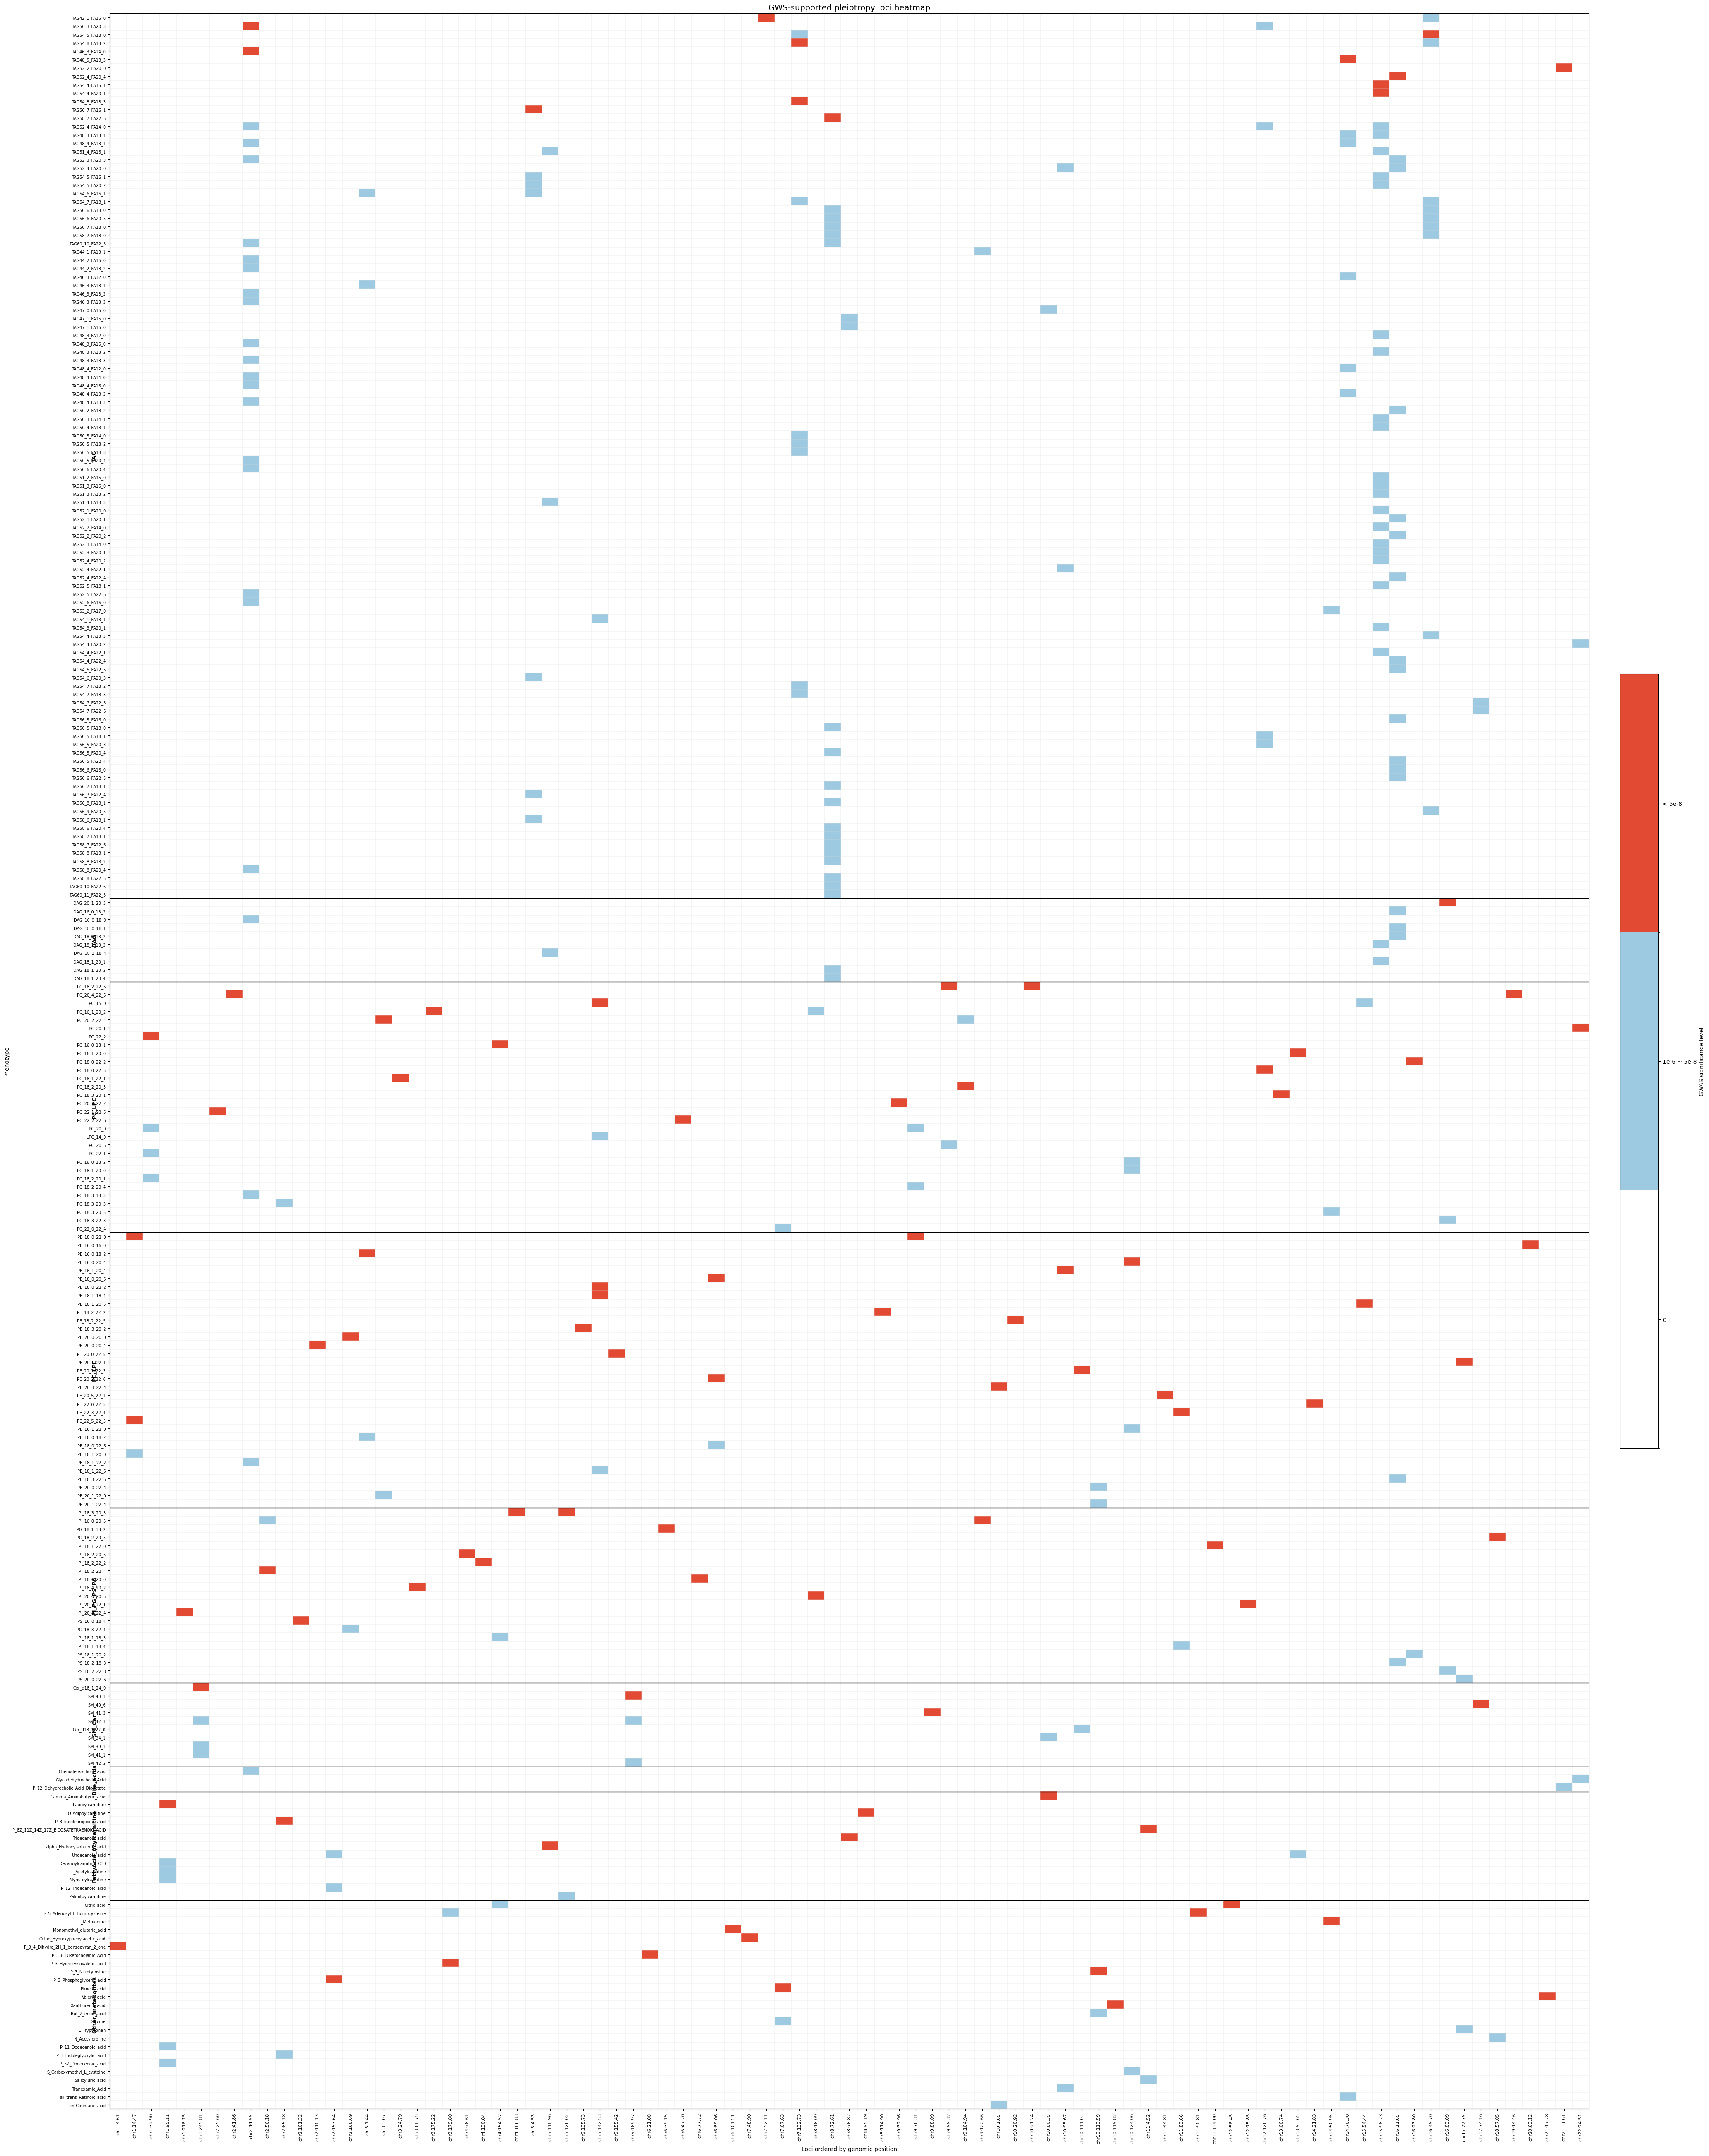

saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/pleiotropy_plots/pleiotropy_heatmap_grouped_gws_blocks_sorted_by_pos.png
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/pleiotropy_plots/pleiotropy_heatmap_grouped_gws_blocks_sorted_by_pos.locus_table.tsv
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/pleiotropy_plots/pleiotropy_heatmap_grouped_gws_blocks_sorted_by_pos.phenotype_group.tsv

[summary]
filter note: non-singleton filter by n_snp >= 2
n loci: 89
n phenotypes: 251

[group counts]
group
TAG                        106
DAG                         10
PC_LPC                      30
PE_LPE                      33
PI_PG_PS_PA                 21
SM_Cer                      10
CE                           0
Bile_acids                   3
FattyAcid_Acylcarnitine     13
Other_metabolites           25
Name: count, dtype: int64


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import re

# =========================
# 路径
# =========================
PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"
OUT_DIR = SUMMARY_DIR / "pleiotropy_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PLEIO_FILE = SUMMARY_DIR / "pleiotropy_summary.tsv"
MEMBER_FILE = SUMMARY_DIR / "pleiotropy_members.tsv"
GENE_ANNO_FILE = PROJECT_ROOT / "data/annotations/KnownCanonicalGene.Drop.hg38.txt"

pleio = pd.read_csv(PLEIO_FILE, sep="\t")
members = pd.read_csv(MEMBER_FILE, sep="\t")
gene_anno = pd.read_csv(GENE_ANNO_FILE, sep="\t")

# =========================
# 参数
# =========================
SUGGESTIVE_P = 1e-6
GWS_P = 5e-8
USE_MB_RANGE = True

# 如果图太高，可以改成 120 / 150；None = 全部 phenotype 都画
TOP_PHENOTYPES = None

# 候选 gene 最多展示几个
MAX_GENE_SHOW = 2

# 输出前缀
OUT_PREFIX = "pleiotropy_heatmap_grouped_gws_blocks_sorted_by_pos"

# =========================
# 整理基因注释表
# =========================
gene_anno = gene_anno.rename(columns={
    "#hg38.knownCanonical.chrom": "chrom",
    "hg38.knownCanonical.chromStart": "gene_start",
    "hg38.knownCanonical.chromEnd": "gene_end",
    "hg38.knownGene.strand": "strand",
    "hg38.kgXref.geneSymbol": "gene_symbol",
    "hg38.kgXref.description": "gene_description",
}).copy()

gene_anno["chrom"] = gene_anno["chrom"].astype(str)
gene_anno["gene_start"] = pd.to_numeric(gene_anno["gene_start"], errors="coerce")
gene_anno["gene_end"] = pd.to_numeric(gene_anno["gene_end"], errors="coerce")
gene_anno = gene_anno.dropna(subset=["chrom", "gene_start", "gene_end", "gene_symbol"]).copy()

# =========================
# 辅助函数
# =========================
def chr_sort_key(x):
    s = str(x).replace("chr", "").replace("CHR", "").strip()
    if s in {str(i) for i in range(1, 23)}:
        return int(s)
    if s == "X":
        return 23
    if s == "Y":
        return 24
    if s in {"M", "MT"}:
        return 25
    return 999

def format_region(chrom, start, end, use_mb=True):
    chrom = str(chrom).replace("chr", "")
    start = int(start)
    end = int(end)
    if use_mb:
        return f"chr{chrom}:{start/1e6:.2f}-{end/1e6:.2f}Mb"
    return f"chr{chrom}:{start:,}-{end:,}"

def get_overlap_genes(chrom, start, end, gene_df, max_gene_show=2):
    chrom = str(chrom)
    if not chrom.startswith("chr"):
        chrom = f"chr{chrom}"

    sub = gene_df[gene_df["chrom"] == chrom].copy()
    if sub.empty:
        return {
            "display_gene": "NA",
            "gene_symbols_all": "",
            "gene_description_short": "",
            "n_genes_overlap": 0,
        }

    ov = sub[(sub["gene_end"] >= start) & (sub["gene_start"] <= end)].copy()

    if not ov.empty:
        ov["overlap_bp"] = np.minimum(ov["gene_end"], end) - np.maximum(ov["gene_start"], start) + 1
        ov = ov.sort_values(["overlap_bp", "gene_start"], ascending=[False, True])
        genes = ov["gene_symbol"].drop_duplicates().tolist()
        descs = ov.drop_duplicates("gene_symbol")[["gene_symbol", "gene_description"]]
    else:
        mid = (start + end) / 2
        sub["dist_to_mid"] = np.minimum(abs(sub["gene_start"] - mid), abs(sub["gene_end"] - mid))
        sub = sub.sort_values(["dist_to_mid", "gene_start"], ascending=[True, True])
        genes = sub["gene_symbol"].drop_duplicates().tolist()
        descs = sub.drop_duplicates("gene_symbol")[["gene_symbol", "gene_description"]]

    shown = genes[:max_gene_show]
    display_gene = "/".join(shown) if shown else "NA"
    if len(genes) > max_gene_show:
        display_gene += "+"

    desc_map = dict(zip(descs["gene_symbol"], descs["gene_description"]))
    short_desc = " | ".join([f"{g}: {desc_map.get(g, '')}" for g in shown])

    return {
        "display_gene": display_gene,
        "gene_symbols_all": ";".join(genes),
        "gene_description_short": short_desc,
        "n_genes_overlap": len(genes),
    }

def phenotype_group(pheno: str) -> str:
    s = str(pheno)
    su = s.upper()
    sl = s.lower()

    # ===== lipid =====
    if su.startswith("TAG") or re.match(r"^TAG\d+_", su):
        return "TAG"
    if su.startswith("TG_"):
        return "TAG"

    if su.startswith("DAG"):
        return "DAG"
    if su.startswith("DG_"):
        return "DAG"

    if su.startswith("PC_") or su.startswith("LPC_"):
        return "PC_LPC"

    if su.startswith("PE_") or su.startswith("LPE_"):
        return "PE_LPE"

    if (
        su.startswith("PI_") or su.startswith("PG_") or su.startswith("PS_")
        or su.startswith("PA_") or su.startswith("LPA_")
        or su.startswith("LPI_") or su.startswith("LPG_") or su.startswith("LPS_")
    ):
        return "PI_PG_PS_PA"

    if su.startswith("SM_") or su.startswith("CER_"):
        return "SM_Cer"

    if su.startswith("CE_"):
        return "CE"

    if su.startswith("FA_") or su.startswith("AC_") or su.startswith("MG_"):
        return "FattyAcid_Acylcarnitine"

    # ===== metabolite =====
    bile_keywords = [
        "cholic", "cholate", "chenodeoxycholic", "deoxycholic",
        "ursodeoxycholic", "lithocholic", "muricholic",
        "glycocholic", "glycochenodeoxycholic", "glycodeoxycholic",
        "glycoursodeoxycholic", "taurocholic", "taurochenodeoxycholic",
        "taurodeoxycholic", "taurolithocholic", "hyocholic",
        "hyodeoxycholic", "ketolithocholic", "allolithocholic",
        "dehydrocholic", "apocholic", "dioxolithocholic"
    ]
    if any(k in sl for k in bile_keywords):
        return "Bile_acids"

    fatty_keywords = [
        "carnitine", "linolenic", "linoleic", "oleic", "palmit", "stear",
        "arachid", "arachidonic", "eicosa", "docosa", "adrenic", "erucic",
        "laur", "myrist", "decanoic", "dodecanoic", "octadecenoic",
        "hexadecenoic", "hexadecanoic", "octadecanoic", "butyric",
        "propionic", "succinic", "adipic", "suberic", "azelaic"
    ]
    if any(k in sl for k in fatty_keywords):
        return "FattyAcid_Acylcarnitine"

    return "Other_metabolites"

group_order = [
    "TAG",
    "DAG",
    "PC_LPC",
    "PE_LPE",
    "PI_PG_PS_PA",
    "SM_Cer",
    "CE",
    "Bile_acids",
    "FattyAcid_Acylcarnitine",
    "Other_metabolites",
]

# =========================
# 1. 只保留含有 GWS 命中的 locus
# =========================
members = members.copy()
members["top_p"] = pd.to_numeric(members["top_p"], errors="coerce")
members = members.dropna(subset=["top_p"]).copy()
members["is_gws"] = members["top_p"] < GWS_P

gws_blocks = (
    members.loc[members["is_gws"], "pleiotropy_block_id"]
    .dropna()
    .unique()
    .tolist()
)

plot_pleio = pleio[pleio["pleiotropy_block_id"].isin(gws_blocks)].copy()
plot_members = members[members["pleiotropy_block_id"].isin(gws_blocks)].copy()

# =========================
# 2. 尽量过滤“单点”
# 自动找支持列；如果找不到，就退回到较宽松规则
# =========================
support_cols_priority = [
    "block_n_p_lt_1e5",
    "window_n_p_lt_1e5",
    "n_p_lt_1e5",
    "n_snp",
    "n_snps",
    "n_variants",
]

used_support_col = None
for col in support_cols_priority:
    if col in plot_members.columns:
        used_support_col = col
        break

if used_support_col is not None:
    tmp = plot_members.copy()
    tmp[used_support_col] = pd.to_numeric(tmp[used_support_col], errors="coerce")
    block_support = (
        tmp.groupby("pleiotropy_block_id", as_index=False)[used_support_col]
        .max()
        .rename(columns={used_support_col: "support_value"})
    )
    # 至少 2 个支持 SNP / supporting variants
    block_support["keep_non_singleton"] = block_support["support_value"] >= 2
    keep_blocks = block_support.loc[block_support["keep_non_singleton"], "pleiotropy_block_id"].tolist()
    filter_note = f"non-singleton filter by {used_support_col} >= 2"
else:
    # 如果没有更直接的支持列，就用较宽松的 block 级信息
    if "n_significant" in plot_pleio.columns:
        tmp = plot_pleio.copy()
        tmp["n_significant"] = pd.to_numeric(tmp["n_significant"], errors="coerce").fillna(0)
        keep_blocks = tmp.loc[tmp["n_significant"] >= 1, "pleiotropy_block_id"].tolist()
        filter_note = "fallback filter by n_significant >= 1"
    else:
        keep_blocks = plot_pleio["pleiotropy_block_id"].tolist()
        filter_note = "no explicit non-singleton column found; keep all GWS-supported loci"

plot_pleio = plot_pleio[plot_pleio["pleiotropy_block_id"].isin(keep_blocks)].copy()
plot_members = plot_members[plot_members["pleiotropy_block_id"].isin(keep_blocks)].copy()

if len(plot_pleio) == 0:
    raise ValueError("过滤后没有可画的 locus。请检查输入表，或放宽过滤条件。")

# =========================
# 3. locus 按 chr + pos 排序
# =========================
plot_pleio["chrom_sort"] = plot_pleio["chrom"].map(chr_sort_key)
plot_pleio["start"] = pd.to_numeric(plot_pleio["start"], errors="coerce")
plot_pleio["end"] = pd.to_numeric(plot_pleio["end"], errors="coerce")

plot_pleio = plot_pleio.sort_values(
    ["chrom_sort", "start", "end", "pleiotropy_block_id"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

plot_blocks = plot_pleio["pleiotropy_block_id"].tolist()

# x轴简短标签：chr:start(Mb)
plot_pleio["x_label"] = plot_pleio.apply(
    lambda r: f"chr{str(r['chrom']).replace('chr','')}:{float(r['start'])/1e6:.2f}",
    axis=1
)
block2label = dict(zip(plot_pleio["pleiotropy_block_id"], plot_pleio["x_label"]))

# =========================
# 4. 给 locus 做 gene 注释（导出表用，图上不写长标签）
# =========================
anno_records = []
for _, r in plot_pleio.iterrows():
    gene_info = get_overlap_genes(
        chrom=r["chrom"],
        start=int(r["start"]),
        end=int(r["end"]),
        gene_df=gene_anno,
        max_gene_show=MAX_GENE_SHOW,
    )
    rec = {
        "pleiotropy_block_id": r["pleiotropy_block_id"],
        "chrom": r["chrom"],
        "start": int(r["start"]),
        "end": int(r["end"]),
        "x_label": block2label[r["pleiotropy_block_id"]],
        "region_label": format_region(r["chrom"], r["start"], r["end"], use_mb=USE_MB_RANGE),
    }
    rec.update(gene_info)
    anno_records.append(rec)

locus_anno = pd.DataFrame(anno_records)

# 统计每个 locus 在图中的命中数
locus_counts = (
    plot_members.groupby("pleiotropy_block_id", as_index=False)
    .agg(
        n_pheno_plot=("phenotype", "nunique"),
        n_gws_cells=("is_gws", "sum")
    )
)

locus_anno = locus_anno.merge(locus_counts, on="pleiotropy_block_id", how="left")

# =========================
# 5. 信号分层
# 0 = 无
# 1 = 1e-6 ~ 5e-8
# 2 = < 5e-8
# =========================
plot_members["level"] = 0
plot_members.loc[
    (plot_members["top_p"] <= SUGGESTIVE_P) & (plot_members["top_p"] >= GWS_P),
    "level"
] = 1
plot_members.loc[plot_members["top_p"] < GWS_P, "level"] = 2

mat = plot_members.pivot_table(
    index="phenotype",
    columns="pleiotropy_block_id",
    values="level",
    aggfunc="max",
    fill_value=0
)

# 保证列顺序
mat = mat.reindex(columns=plot_blocks, fill_value=0)

# =========================
# 6. phenotype 分组并排序
# =========================
pheno_meta = pd.DataFrame({"phenotype": mat.index})
pheno_meta["group"] = pheno_meta["phenotype"].map(phenotype_group)
pheno_meta["group"] = pd.Categorical(pheno_meta["group"], categories=group_order, ordered=True)
pheno_meta["n_gws"] = (mat == 2).sum(axis=1).values
pheno_meta["n_sug"] = (mat == 1).sum(axis=1).values
pheno_meta["row_sum"] = mat.sum(axis=1).values

pheno_meta = pheno_meta.sort_values(
    ["group", "n_gws", "n_sug", "row_sum", "phenotype"],
    ascending=[True, False, False, False, True]
).reset_index(drop=True)

mat = mat.loc[pheno_meta["phenotype"]]

if TOP_PHENOTYPES is not None and len(mat) > TOP_PHENOTYPES:
    pheno_meta = pheno_meta.iloc[:TOP_PHENOTYPES, :].copy()
    mat = mat.loc[pheno_meta["phenotype"]]

# 只保留至少有一个非零格子的 phenotype
keep_pheno = pheno_meta.loc[(mat > 0).sum(axis=1).values > 0, "phenotype"].tolist()
pheno_meta = pheno_meta[pheno_meta["phenotype"].isin(keep_pheno)].reset_index(drop=True)
mat = mat.loc[keep_pheno]

# =========================
# 7. 作图
# =========================
cmap = ListedColormap([
    "#ffffff",   # 0
    "#9ecae1",   # 1e-6 ~ 5e-8
    "#e34a33",   # < 5e-8
])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig_w = max(10, 0.42 * mat.shape[1] + 4)
fig_h = max(8, 0.20 * mat.shape[0] + 2)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
im = ax.imshow(mat.values, aspect="auto", cmap=cmap, norm=norm)

# x轴：按 chr+pos 排序后的 locus
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels([block2label.get(c, c) for c in mat.columns], rotation=90, fontsize=8)

# y轴：phenotype
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(mat.index, fontsize=7)

ax.set_title("GWS-supported pleiotropy loci heatmap", fontsize=14)
ax.set_xlabel("Loci ordered by genomic position")
ax.set_ylabel("Phenotype")

# 网格线
ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
ax.grid(which="minor", color="#d9d9d9", linestyle="-", linewidth=0.35)
ax.tick_params(which="minor", bottom=False, left=False)

# phenotype 分组分隔线
group_breaks = []
prev_group = None
for i, g in enumerate(pheno_meta["group"].astype(str)):
    if prev_group is None:
        prev_group = g
        continue
    if g != prev_group:
        group_breaks.append(i - 0.5)
        prev_group = g

for y in group_breaks:
    ax.hlines(y, xmin=-0.5, xmax=mat.shape[1] - 0.5, colors="black", linewidth=1.0)

# 左侧分组名
group_pos = (
    pheno_meta.reset_index()
    .groupby("group", observed=False)["index"]
    .agg(["min", "max"])
    .reset_index()
)

for _, row in group_pos.iterrows():
    if pd.isna(row["min"]) or pd.isna(row["max"]):
        continue
    y_mid = (row["min"] + row["max"]) / 2
    ax.text(
        -1.25, y_mid, str(row["group"]),
        va="center", ha="right",
        fontsize=9.5, fontweight="bold",
        rotation=90
    )

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(["0", "1e-6 ~ 5e-8", "< 5e-8"])
cbar.set_label("GWAS significance level")

plt.tight_layout()

# 先展示
plt.show()

# 保存
out_png = OUT_DIR / f"{OUT_PREFIX}.png"
fig.savefig(out_png, dpi=250, bbox_inches="tight")
print("saved:", out_png)

plt.close(fig)

# =========================
# 8. 导出辅助表
# =========================
locus_file = OUT_DIR / f"{OUT_PREFIX}.locus_table.tsv"
locus_anno.to_csv(locus_file, sep="\t", index=False)
print("saved:", locus_file)

pheno_file = OUT_DIR / f"{OUT_PREFIX}.phenotype_group.tsv"
pheno_meta.to_csv(pheno_file, sep="\t", index=False)
print("saved:", pheno_file)

# 简单打印一下信息，方便你检查
print("\n[summary]")
print("filter note:", filter_note)
print("n loci:", mat.shape[1])
print("n phenotypes:", mat.shape[0])
print("\n[group counts]")
print(pheno_meta["group"].value_counts().reindex(group_order).fillna(0).astype(int))

### 每个表型的 SNP heritability（GCTA GREML）

这里用 GCTA GREML 估算每个 phenotype 的 SNP heritability。

流程：
1. 从 GWAS 用的 pfile 转成 bed/bim/fam（如果还没有）
2. 基于 autosome SNP 构建一次 GRM
3. 逐个 phenotype 跑 REML
4. 汇总每个 phenotype 的 h2、SE、P 值和状态

注意：
- 小样本下 h2 估计可能不稳定，SE 会较大
- 个别 phenotype 可能失败或不收敛
- 结果更适合做全局排序和粗筛

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import subprocess
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

# =========================
# 路径与参数
# =========================
PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")

PLINK2 = shutil.which("plink2") or "/mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/plink2"
GCTA = shutil.which("gcta64") or "/mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/gcta64"

PFILE = PROJECT_ROOT / "data/processed/genotype/CIMA_BGEID_metaMatched"
PHENO_FILE = PROJECT_ROOT / "data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.safe.tsv"
COVAR_FILE = PROJECT_ROOT / "data/processed/meta/CIMA_plink_covariates.tsv"

OUT_DIR = PROJECT_ROOT / "data/results/heritability_greml"

# 改这里：单独做 biallelic SNP 版 bed / grm
BED_PREFIX = OUT_DIR / "CIMA_BGEID_metaMatched.biallelic"
GRM_PREFIX = OUT_DIR / "CIMA_BGEID_metaMatched.biallelic.autosome"

PER_PHENO_DIR = OUT_DIR / "per_pheno"
LOG_DIR = OUT_DIR / "logs"
TMP_DIR = OUT_DIR / "tmp"

for d in [OUT_DIR, PER_PHENO_DIR, LOG_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

N_JOBS = 8
THREAD_PER_JOB = 2

# 与 GWAS 保持一致
CAT_COVARS = ["SEX"]
Q_COVARS = ["age", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]

# 可选：有效样本数太少的表型先不跑
MIN_NON_MISSING = 300

print("PLINK2:", PLINK2)
print("GCTA:", GCTA)

# =========================
# 基本检查
# =========================
for exe in [PLINK2, GCTA]:
    if not Path(exe).exists():
        raise FileNotFoundError(f"not found: {exe}")

for f in [PHENO_FILE, COVAR_FILE]:
    if not f.exists():
        raise FileNotFoundError(f)

for suffix in [".pgen", ".pvar", ".psam"]:
    if not Path(str(PFILE) + suffix).exists():
        raise FileNotFoundError(f"missing genotype file: {str(PFILE) + suffix}")

# =========================
# 小工具
# =========================
def run_cmd(cmd, step_name, log_hint=None):
    print(f"\n[{step_name}]")
    print(" ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)

    print("returncode:", res.returncode)
    if res.stdout:
        print("\n[stdout tail]")
        print(res.stdout[-3000:])
    if res.stderr:
        print("\n[stderr tail]")
        print(res.stderr[-3000:])

    if res.returncode != 0:
        msg = f"{step_name} failed"
        if log_hint is not None:
            msg += f"; see log: {log_hint}"
        raise RuntimeError(msg)

def safe_name(s: str) -> str:
    return (
        str(s)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace(";", "_")
        .replace(",", "_")
    )

def parse_hsq(hsq_path: Path):
    rec = {
        "n": np.nan,
        "vg": np.nan,
        "ve": np.nan,
        "vp": np.nan,
        "h2": np.nan,
        "h2_se": np.nan,
        "pval": np.nan,
        "logL": np.nan,
    }
    if not hsq_path.exists():
        return rec

    with open(hsq_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue

            if parts[0] == "V(G)":
                rec["vg"] = float(parts[1])
            elif parts[0] == "V(e)":
                rec["ve"] = float(parts[1])
            elif parts[0] == "Vp":
                rec["vp"] = float(parts[1])
            elif parts[0] == "V(G)/Vp":
                rec["h2"] = float(parts[1])
                if len(parts) >= 3:
                    rec["h2_se"] = float(parts[2])
            elif parts[0] == "Pval":
                rec["pval"] = float(parts[1])
            elif parts[0] == "logL":
                rec["logL"] = float(parts[1])
            elif parts[0] == "n":
                rec["n"] = float(parts[1])

    return rec

# =========================
# 1. 读取 phenotype / covariate
# =========================
pheno_df = pd.read_csv(PHENO_FILE, sep="\t")
covar_df = pd.read_csv(COVAR_FILE, sep="\t")

if not {"FID", "IID"}.issubset(pheno_df.columns):
    raise ValueError("PHENO_FILE 必须包含 FID, IID")
if not {"FID", "IID"}.issubset(covar_df.columns):
    raise ValueError("COVAR_FILE 必须包含 FID, IID")

missing_cat = [c for c in CAT_COVARS if c not in covar_df.columns]
missing_q = [c for c in Q_COVARS if c not in covar_df.columns]
if missing_cat:
    raise ValueError(f"COVAR_FILE 缺少分类协变量列: {missing_cat}")
if missing_q:
    raise ValueError(f"COVAR_FILE 缺少连续协变量列: {missing_q}")

pheno_cols = [c for c in pheno_df.columns if c not in ["FID", "IID"]]
print("phenotype count (raw):", len(pheno_cols))

# 过滤有效样本数太少的 phenotype
pheno_non_missing = pheno_df[pheno_cols].notna().sum().sort_values(ascending=False)
keep_phenos = pheno_non_missing[pheno_non_missing >= MIN_NON_MISSING].index.tolist()

print(f"phenotype count (non-missing >= {MIN_NON_MISSING}):", len(keep_phenos))

pheno_manifest = pd.DataFrame({
    "phenotype": pheno_non_missing.index,
    "n_non_missing": pheno_non_missing.values,
    "keep_for_greml": pheno_non_missing.index.isin(keep_phenos)
})
pheno_manifest_file = OUT_DIR / "phenotype_manifest_for_greml.tsv"
pheno_manifest.to_csv(pheno_manifest_file, sep="\t", index=False)
print("saved:", pheno_manifest_file)

# =========================
# 2. 生成 bed/bim/fam（biallelic SNP only）
# =========================
bed_exists = (
    BED_PREFIX.with_suffix(".bed").exists()
    and BED_PREFIX.with_suffix(".bim").exists()
    and BED_PREFIX.with_suffix(".fam").exists()
)

if not bed_exists:
    cmd = [
        str(PLINK2),
        "--pfile", str(PFILE),
        "--chr", "1-22",
        "--max-alleles", "2",
        "--snps-only", "just-acgt",
        "--make-bed",
        "--out", str(BED_PREFIX),
        "--threads", "8",
        "--memory", "32000",
    ]
    run_cmd(cmd, "make-bed(biallelic SNP only)", log_hint=str(BED_PREFIX) + ".log")
else:
    print("\n[make-bed] exists, skip")

# =========================
# 3. 构建 GRM（如果没有）
# =========================
grm_exists = (
    Path(str(GRM_PREFIX) + ".grm.bin").exists()
    and Path(str(GRM_PREFIX) + ".grm.N.bin").exists()
    and Path(str(GRM_PREFIX) + ".grm.id").exists()
)

if not grm_exists:
    cmd = [
        str(GCTA),
        "--bfile", str(BED_PREFIX),
        "--make-grm",
        "--out", str(GRM_PREFIX),
        "--thread-num", "16",
    ]
    run_cmd(cmd, "make-grm", log_hint=str(GRM_PREFIX) + ".log")
else:
    print("\n[make-grm] exists, skip")

# =========================
# 4. 单 phenotype 运行函数
# =========================
def run_one(pheno: str):
    sname = safe_name(pheno)
    ph_dir = PER_PHENO_DIR / sname
    ph_dir.mkdir(parents=True, exist_ok=True)

    one_pheno_file = ph_dir / f"{sname}.pheno.tsv"
    one_covar_file = ph_dir / f"{sname}.covar.tsv"
    one_qcovar_file = ph_dir / f"{sname}.qcovar.tsv"
    out_prefix = ph_dir / sname
    hsq_file = ph_dir / f"{sname}.hsq"

    if hsq_file.exists():
        return {"phenotype": pheno, "status": "skip_exists", "out_prefix": str(out_prefix)}

    # 生成单 phenotype 文件
    ph_sub = pheno_df.loc[:, ["FID", "IID", pheno]].copy()
    ph_sub.to_csv(one_pheno_file, sep="\t", index=False)

    # 生成单独的分类协变量文件
    covar_sub = covar_df.loc[:, ["FID", "IID"] + CAT_COVARS].copy()
    covar_sub.to_csv(one_covar_file, sep="\t", index=False)

    # 生成单独的连续协变量文件
    qcovar_sub = covar_df.loc[:, ["FID", "IID"] + Q_COVARS].copy()
    qcovar_sub.to_csv(one_qcovar_file, sep="\t", index=False)

    stdout_log = LOG_DIR / f"{sname}.stdout.log"
    stderr_log = LOG_DIR / f"{sname}.stderr.log"

    cmd = [
        str(GCTA),
        "--grm", str(GRM_PREFIX),
        "--pheno", str(one_pheno_file),
        "--reml",
        "--reml-no-constrain",
        "--covar", str(one_covar_file),
        "--qcovar", str(one_qcovar_file),
        "--out", str(out_prefix),
        "--thread-num", str(THREAD_PER_JOB),
    ]

    try:
        with open(stdout_log, "w") as fout, open(stderr_log, "w") as ferr:
            ret = subprocess.run(cmd, stdout=fout, stderr=ferr)
        if ret.returncode == 0 and hsq_file.exists():
            status = "ok"
        else:
            status = f"failed_returncode_{ret.returncode}"
    except Exception as e:
        status = f"exception:{e}"

    return {"phenotype": pheno, "status": status, "out_prefix": str(out_prefix)}

# =========================
# 5. 并行跑
# =========================
print("\n[run greml]")
run_records = []

with ThreadPoolExecutor(max_workers=N_JOBS) as ex:
    futs = {ex.submit(run_one, ph): ph for ph in keep_phenos}
    for i, fut in enumerate(as_completed(futs), 1):
        rec = fut.result()
        run_records.append(rec)
        if i % 20 == 0 or i == len(futs):
            ok_n = sum(r["status"] in {"ok", "skip_exists"} for r in run_records)
            print(f"done {i}/{len(futs)} | ok_or_skip={ok_n}")

run_df = pd.DataFrame(run_records)
run_status_file = OUT_DIR / "run_status.tsv"
run_df.to_csv(run_status_file, sep="\t", index=False)
print("saved:", run_status_file)

# =========================
# 6. 汇总 hsq
# =========================
summary_records = []
for ph in keep_phenos:
    sname = safe_name(ph)
    ph_dir = PER_PHENO_DIR / sname
    hsq_file = ph_dir / f"{sname}.hsq"

    run_status = run_df.loc[run_df["phenotype"] == ph, "status"]
    status = run_status.iloc[0] if len(run_status) else "missing"

    rec = {
        "phenotype": ph,
        "n_non_missing_input": int(pheno_non_missing[ph]),
        "status": status,
    }
    rec.update(parse_hsq(hsq_file))
    summary_records.append(rec)

summary_df = pd.DataFrame(summary_records)
summary_df["h2_z"] = summary_df["h2"] / summary_df["h2_se"]
summary_df["h2_lower95"] = summary_df["h2"] - 1.96 * summary_df["h2_se"]
summary_df["h2_upper95"] = summary_df["h2"] + 1.96 * summary_df["h2_se"]

summary_df = summary_df.sort_values(
    ["status", "h2_z", "h2"],
    ascending=[True, False, False]
).reset_index(drop=True)

summary_file = OUT_DIR / "heritability_summary.tsv"
summary_df.to_csv(summary_file, sep="\t", index=False)
print("saved:", summary_file)

print("\n[status counts]")
print(summary_df["status"].value_counts(dropna=False))

print("\n[top 20 by h2_z]")
display(summary_df.head(20))

PLINK2: /mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/plink2
GCTA: /mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/gcta64
phenotype count (raw): 1549
phenotype count (non-missing >= 300): 945
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml/phenotype_manifest_for_greml.tsv

[make-bed(biallelic SNP only)]
/mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/plink2 --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched --chr 1-22 --max-alleles 2 --snps-only just-acgt --make-bed --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml/CIMA_BGEID_metaMatched.biallelic --threads 8 --memory 32000
returncode: 0

[stdout tail]
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation

,phenotype,n_non_missing_input,status,n,vg,ve,vp,h2,h2_se,pval,logL,h2_z,h2_lower95,h2_upper95
0,Choleic_Acid,390,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P_3_Hydroxyhippuric,390,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TAG49_2_FA14_0,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TAG54_5_FA16_1,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TAG48_2_FA14_0,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,TAG46_2_FA14_1,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,TAG45_0_FA14_0,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,TAG46_4_FA18_2,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,TAG54_5_FA20_4,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,TAG54_5_FA18_0,389,failed_returncode_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
